<a href="https://colab.research.google.com/github/Ebbiebab/Nano706-Work/blob/main/Exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# Load the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [2]:
# Load the Wine Quality dataset
wine = datasets.load_wine()
X = wine.data  # Features
y = wine.target  # Target variable (wine quality)

# Create a DataFrame for better visualization
wine_df = pd.DataFrame(X, columns=wine.feature_names)
wine_df['target'] = y

# Display the feature names
print("Feature names:", wine.feature_names)
# Display the first few rows of the dataset
wine_df.head()


Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


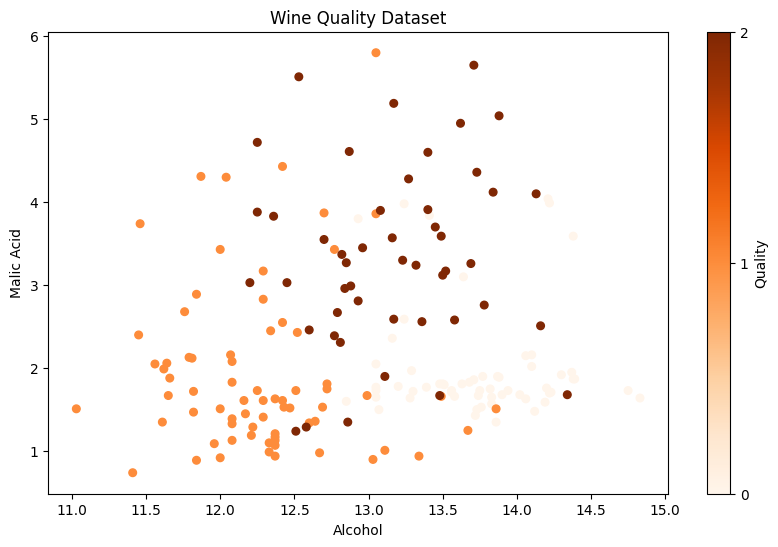

In [31]:
# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(wine_df['alcohol'], wine_df['malic_acid'], c=wine_df['target'], cmap='Oranges', s=30)

"""
use data visualization notebook:
set the title to "Wine Quality Dataset"
set the xlabel to "Alcohol"
set the ylabel to "Malic Acid"
"""

plt.title("Wine Quality Dataset")
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")

plt.colorbar(ticks=np.unique(y), label='Quality')
plt.show()


In [4]:
# Standardize features
scaler = StandardScaler()
X2 = scaler.fit_transform(X)  # Standardize features

In [7]:
# Split raw features (for trees/forests)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [9]:
# Train the SVM on standardized data
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [19]:
# Make predictions
y_pred_tree = tree.predict(X_test)

# Evaluate model performance
tree_accuracy = accuracy_score(y_test, y_pred_tree)
print(f"Accuracy of the Decision Tree model: {tree_accuracy:.2f}")



Accuracy of the Decision Tree model: 0.96


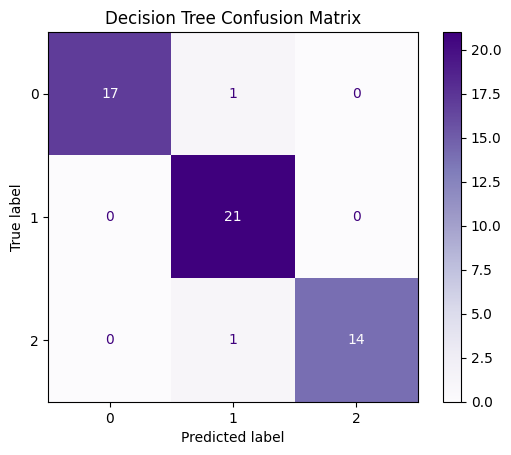

In [25]:
""" Visualization of decision tree (Graphviz) """

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, cmap="Purples")
plt.title("Decision Tree Confusion Matrix")
plt.show()

Accuracy of the Logistic Regression model: 0.98


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


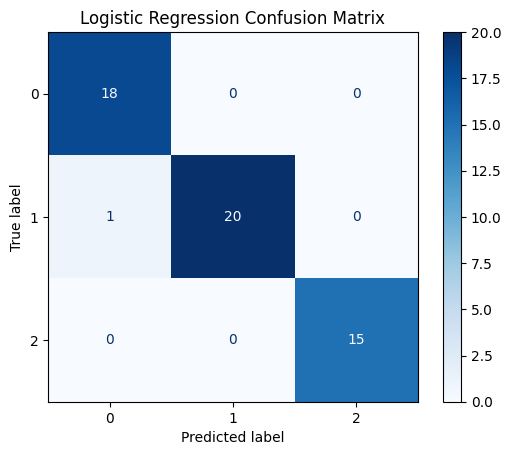

In [29]:
""" Train the Logistic Regression model """

# Split standardized features
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y)

log_reg = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="auto", random_state=42)
log_reg.fit(X2_train, y_train)

""" Make predictions """

y_pred_log = log_reg.predict(X2_test)

""" Evaluate the model """

log_acc = accuracy_score(y_test, y_pred_log)
print(f"Accuracy of the Logistic Regression model: {log_acc:.2f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()